# Face Alignment

## Выбор датасета

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Как я фильтровал датасет и что именно отбросил:

Для того чтобы наша будущая нейросеть нормально находила ключевые точки на лице, нам нужен был чистый датасет без всякого мусора. Если скормить сетке плохие фотки, она просто сойдет с ума и ничему не научится. Вот какие картинки мы сразу отсеяли через файл атрибутов:

Размытые фотки (Blurry). Если картинка смазанная, то даже человек не всегда поймет, где там заканчивается нос и начинается щека. Нейросеть на таких фотках будет просто угадывать точки рандомно.

Чуваков в очках (Eyeglasses). Оправа может полностью перекрывать глаза или брови, а линзы бликуют. Из-за этого сетка не сможет нормально определять, где находится центр зрачка. Так что очкариков я временно убрал.

Людей в головных уборах (Wearing_Hat). Кепки, шапки и шляпы — это сразу минус лоб и брови. Из за них геометрия лица ломается.

Пышные челки (Bangs): Тут та же история, что и со шляпами. Густая челка наглухо закрывает брови. А брови нам очень нужны как верхняя граница лица для выравнивания.

Прищуренные или закрытые глаза (Narrow_Eyes): Если человек на фото спит, моргнул или жестко зажмурился, то найти зрачок физически невозможно. Если бы это была реальная система фейс контроля, то люди бы перед камерой точно не зевали.

Так, же побеседовав с ментором проекта, я выяснил важную деталь. У нас не закреплено количество уникальных людей. Изначально я скачал 10 000 изображений в которых было 5000 уникальных людей. Это очень много. Если решать задачу через классификацию то у меня прросто не сходилась модель. Как решение я решил ограничитьт людей до 700, а так же сделать на каждого +- 20 фото.

### Скачивание данных

In [ ]:
!mkdir -p /content/temp_faces
!7z x "/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/CelebA/Img/img_celeba.7z/img_celeba.7z.001" -o/content/temp_faces -y


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/Дз Ноу . кт 1/CelebA/Img/img_celeba.7z/                                                                               1 file, 734003200 bytes (700 MiB)

Extracting archive: /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/CelebA/Img/img_celeba.7z/img_celeba.7z.001
  0% 1 Open           --
Path = /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/CelebA/Img/img_celeba.7z/img_celeba.7z.001
Type = Split
Physical Size = 734003200
Volumes = 14
Total Physical Size = 10191072466
----
Path = img_celeba.7z
Size = 10191072466
--
Path = im

In [ ]:
import os
import pandas as pd
import shutil

# Пути
CELEBA_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/CelebA'
ATTR_FILE = os.path.join(CELEBA_DIR, 'Anno/list_attr_celeba.txt')
IDENTITY_FILE = os.path.join(CELEBA_DIR, 'Anno/identity_CelebA.txt')
UNZIPPED_DIR = '/content/temp_faces/img_celeba'
LOCAL_DATASET_DIR = '/content/clean_dataset'
if os.path.exists(LOCAL_DATASET_DIR):
    shutil.rmtree(LOCAL_DATASET_DIR)
os.makedirs(LOCAL_DATASET_DIR, exist_ok=True)

# 1. Читаем файл атрибутов качества
print("Читаем атрибуты...")
df_attr = pd.read_csv(ATTR_FILE, skiprows=2, header=None, sep=r'\s+',
                      names=['image_id'] + open(ATTR_FILE).readlines()[1].split())

# 2. Читаем файл соответствия картинок и ID людей
print("Читаем индентичности (ID людей)...")
df_ident = pd.read_csv(IDENTITY_FILE, sep=r'\s+', header=None, names=['image_id', 'person_id'])
df_total = pd.merge(df_attr, df_ident, on='image_id')

# 3. Наш жесткий фильтр по качеству
print("Фильтруем по качеству...")
filtered_df = df_total[
    (df_total['Blurry'] == -1) &
    (df_total['Eyeglasses'] == -1) &
    (df_total['Wearing_Hat'] == -1) &
    (df_total['Bangs'] == -1) &
    (df_total['Narrow_Eyes'] == -1)
]

# 4. Магия отбора: ищем людей с максимальным количеством хороших фоток
if not os.path.exists(UNZIPPED_DIR):
    print(f"Ошибка! Папка {UNZIPPED_DIR} не найдена. Распакуй файлы еще раз.")
else:
    available_images = set(os.listdir(UNZIPPED_DIR))
    print(f"Распаковано и доступно на диске Колаба: {len(available_images)} картинок")
    filtered_df = filtered_df[filtered_df['image_id'].isin(available_images)]
    person_counts = filtered_df['person_id'].value_counts()
    top_700_persons = person_counts.index[:700]
    final_selection_df = filtered_df[filtered_df['person_id'].isin(top_700_persons)]
    final_images_df = final_selection_df.groupby('person_id').head(20)

    good_images_list = final_images_df['image_id'].tolist()
    print(f"Итого отобрано: {final_images_df['person_id'].nunique()} уникальных людей.")
    print(f"Суммарное количество картинок для копирования: {len(good_images_list)}")

    saved_count = 0
    selected_images_list = []

    print("Копируем сбалансированные фотки в локальную папку...")
    for filename in good_images_list:
        src_path = os.path.join(UNZIPPED_DIR, filename)
        dst_path = os.path.join(LOCAL_DATASET_DIR, filename)

        if os.path.exists(src_path):
            shutil.copy(src_path, dst_path)
            selected_images_list.append(filename)
            saved_count += 1

    print(f"Успешно скопировано локально: {saved_count} картинок.")

    if saved_count > 0:
        print("Запаковываем новый датасет в ZIP...")
        shutil.make_archive('/content/dataset', 'zip', LOCAL_DATASET_DIR)

        print("Отправляем сбалансированный архив и CSV на Google Диск...")
        GDRIEV_OUTPUT_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'

        shutil.copy('/content/dataset.zip', os.path.join(GDRIEV_OUTPUT_DIR, 'dataset.zip'))

        csv_output_path = os.path.join(GDRIEV_OUTPUT_DIR, 'selected_images.csv')
        df_csv = pd.DataFrame(selected_images_list, columns=['original_image_name'])
        df_csv.to_csv(csv_output_path, index=False)

        print("=== ВСЁ ГОТОВО! ДАТАСЕТ ОБНОВЛЕН ===")

Читаем атрибуты...
Читаем индентичности (ID людей)...
Фильтруем по качеству...
Распаковано и доступно на диске Колаба: 110349 картинок
Итого отобрано: 700 уникальных людей.
Суммарное количество картинок для копирования: 13089
Копируем сбалансированные фотки в локальную папку...
Успешно скопировано локально: 13089 картинок.
Запаковываем новый датасет в ZIP...
Отправляем сбалансированный архив и CSV на Google Диск...
=== ВСЁ ГОТОВО! ДАТАСЕТ ОБНОВЛЕН ===


Я создал архив с 13089 изображениями, сам увидел что твориться с изображениями. Вот мой личный топ.

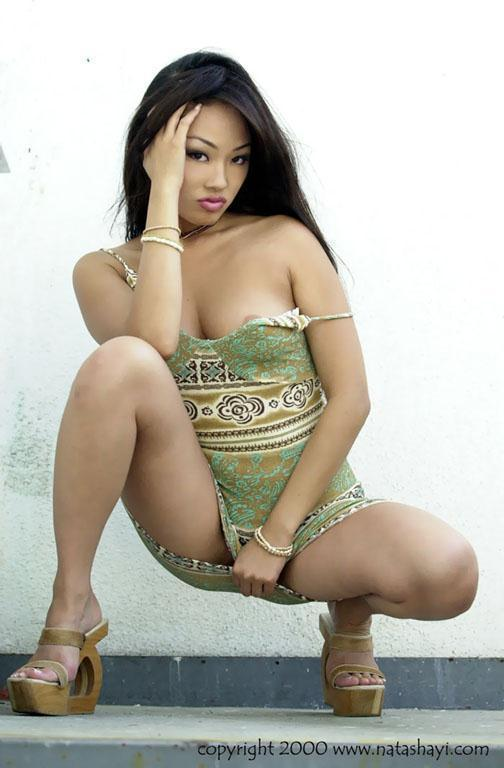

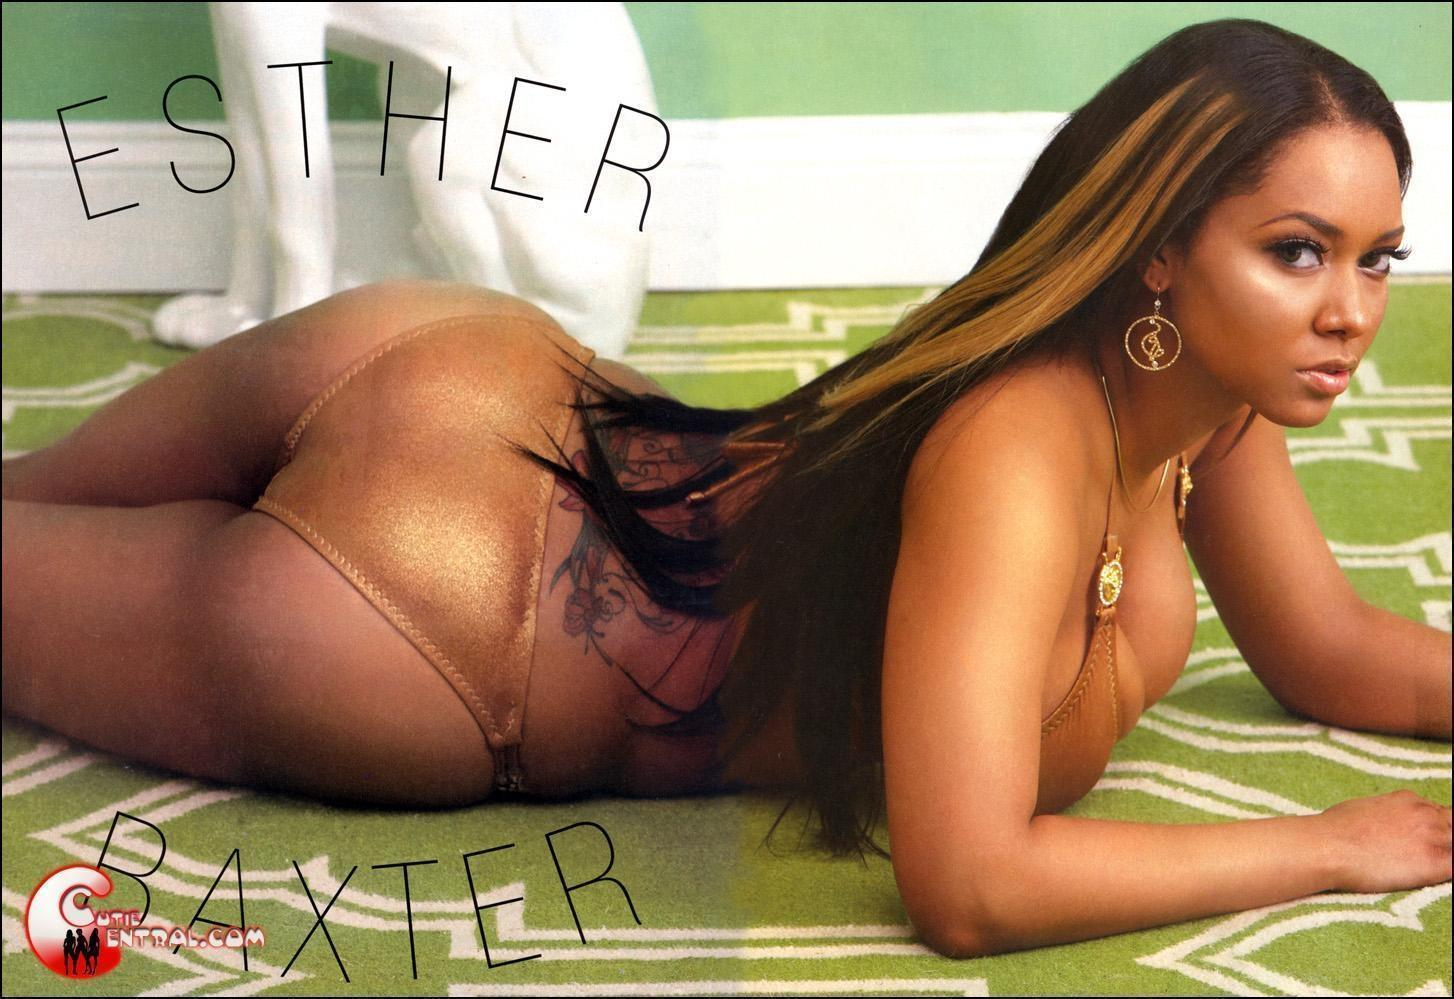

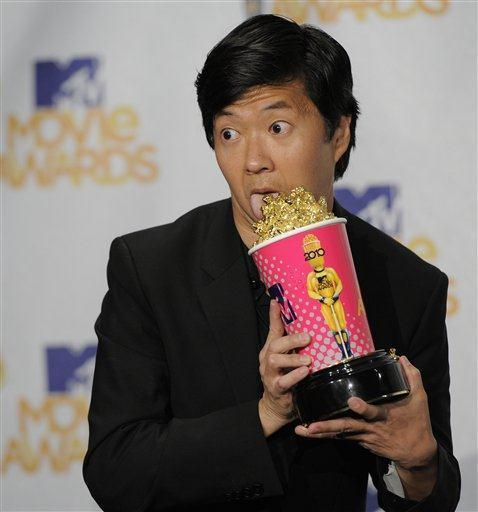

P.S. - изображения выше были в первом датасете, при повторном скачивании они моги как остаться, так и пропасть.

### Нарезка по bbox'ам

Далее обрезка через bbox'ы. Я решил написать код для проверки с простой обрезкой по bboxам и с небольшим паддингом. Когда я изучал вопрос этой задачи я где то видел что простая обрезка может не захватить уши или еще что то важное.

In [ ]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import shutil

PROJECT_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'
BBOX_FILE = os.path.join(PROJECT_DIR, 'CelebA/Anno/list_bbox_celeba.txt')
ZIP_SRC = os.path.join(PROJECT_DIR, 'Dataset/dataset.zip')

LOCAL_IMAGES_DIR = '/content/dataset'

# Проверяем: если папки нет ИЛИ она пустая (длина списка файлов равна 0)
if not os.path.exists(LOCAL_IMAGES_DIR) or len(os.listdir(LOCAL_IMAGES_DIR)) == 0:
    print("Локальная папка пуста или отсутствует. Начинаем распаковку нового сбалансированного датасета...")

    # На всякий случай сносим пустую папку, чтобы unzip создал её сам чисто
    if os.path.exists(LOCAL_IMAGES_DIR):
        shutil.rmtree(LOCAL_IMAGES_DIR)

    os.makedirs(LOCAL_IMAGES_DIR, exist_ok=True)

    # Распаковываем
    !unzip -q "{ZIP_SRC}" -d {LOCAL_IMAGES_DIR}
    print(f"Распаковка завершена! Файлов в папке: {len(os.listdir(LOCAL_IMAGES_DIR))}")
else:
    print(f"Папка уже существует и содержит {len(os.listdir(LOCAL_IMAGES_DIR))} файлов. Пропускаем распаковку.")

print("Читаем bbox'ы...")
df_bbox = pd.read_csv(BBOX_FILE, skiprows=2, header=None, sep=r'\s+',
                      names=['image_id', 'x_1', 'y_1', 'width', 'height'])
df_bbox.set_index('image_id', inplace=True)

# Берем первые 5 картинок из локальной папки нового датасета
selected_images = os.listdir(LOCAL_IMAGES_DIR)[:5]
print(f"Картинки для визуализации: {selected_images}")

if len(selected_images) == 0:
    print("Ошибка! В папке по-прежнему нет картинок. Проверь, лежит ли архив dataset.zip на Диске.")
else:
    # 5 строк (для 5 фоток), в каждой строке по 3 варианта кропа
    fig, axes = plt.subplots(5, 3, figsize=(12, 18))

    for idx, img_name in enumerate(selected_images):
        if img_name not in df_bbox.index:
            print(f"Предупреждение: {img_name} отсутствует в разметке BBox.")
            continue

        img_path = os.path.join(LOCAL_IMAGES_DIR, img_name)

        # Читаем через OpenCV
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"Не удалось прочитать картинку: {img_path}")
            continue

        # Конвертируем BGR -> RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        h_img, w_img, _ = img_rgb.shape

        # Координаты оригинального bbox
        x, y = df_bbox.loc[img_name, 'x_1'], df_bbox.loc[img_name, 'y_1']
        w, h = df_bbox.loc[img_name, 'width'], df_bbox.loc[img_name, 'height']

        # Вариант 1: Строго по разметке (Padding = 0%)
        crop_0 = img_rgb[max(0, y):min(h_img, y+h), max(0, x):min(w_img, x+w)]
        crop_0_res = cv2.resize(crop_0, (256, 256))

        # Вариант 2: Небольшой отступ (Padding = 10%)
        pad_w1, pad_h1 = int(w * 0.10), int(h * 0.10)
        crop_10 = img_rgb[max(0, y-pad_h1):min(h_img, y+h+pad_h1), max(0, x-pad_w1):min(w_img, x+w+pad_w1)]
        crop_10_res = cv2.resize(crop_10, (256, 256))

        # Вариант 3: Оптимальный отступ (Padding = 20%)
        pad_w2, pad_h2 = int(w * 0.20), int(h * 0.20)
        crop_20 = img_rgb[max(0, y-pad_h2):min(h_img, y+h+pad_h2), max(0, x-pad_w2):min(w_img, x+w+pad_w2)]
        crop_20_res = cv2.resize(crop_20, (256, 256))

        # Отрисовываем всё в строчку для текущей картинки
        axes[idx, 0].imshow(crop_0_res)
        axes[idx, 0].set_title(f"{img_name}\nБез отступа (0%)")
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(crop_10_res)
        axes[idx, 1].set_title(f"{img_name}\nОтступ 10%")
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(crop_20_res)
        axes[idx, 2].set_title(f"{img_name}\nОтступ 20%")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

Золото как по мне где то около 10, ближе к 10. 13 наше семейное счастливое число, пусть будет такое.

In [ ]:
import os
import pandas as pd
import cv2
from tqdm import tqdm
import shutil


PROJECT_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'
BBOX_FILE = os.path.join(PROJECT_DIR, 'CelebA/Anno/list_bbox_celeba.txt')
GDRIVE_OUTPUT_DIR = os.path.join(PROJECT_DIR, 'Dataset')
os.makedirs(GDRIVE_OUTPUT_DIR, exist_ok=True)
IMAGES_SRC_DIR = '/content/dataset'
LOCAL_CROPPED_DIR = '/content/cropped_faces'
if os.path.exists(LOCAL_CROPPED_DIR):
    shutil.rmtree(LOCAL_CROPPED_DIR) # Очищаем старое, если было
os.makedirs(LOCAL_CROPPED_DIR, exist_ok=True)

TARGET_SIZE = (256, 256)
PADDING_RATIO = 0.13


print("Загружаем координаты рамок...")
df_bbox = pd.read_csv(BBOX_FILE, skiprows=2, header=None, sep=r'\s+',
                      names=['image_id', 'x_1', 'y_1', 'width', 'height'])
df_bbox.set_index('image_id', inplace=True)

selected_images = os.listdir(IMAGES_SRC_DIR)
print(f"Найдено отобранных картинок в папке: {len(selected_images)}")


print("Начинаем кропать лица...")
cropped_count = 0

for img_name in tqdm(selected_images):
    if img_name not in df_bbox.index:
        continue

    img_path = os.path.join(IMAGES_SRC_DIR, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    h_img, w_img, _ = img.shape

    x = df_bbox.loc[img_name, 'x_1']
    y = df_bbox.loc[img_name, 'y_1']
    w = df_bbox.loc[img_name, 'width']
    h = df_bbox.loc[img_name, 'height']

    # Считаем отступы в пикселях
    pad_w = int(w * PADDING_RATIO)
    pad_h = int(h * PADDING_RATIO)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(w_img, x + w + pad_w)
    y2 = min(h_img, y + h + pad_h)

    # Режем картинку по расширенной рамке
    cropped_face = img[y1:y2, x1:x2]

    # Меняем размер лица на 256x256
    resized_face = cv2.resize(cropped_face, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    out_path = os.path.join(LOCAL_CROPPED_DIR, img_name)
    cv2.imwrite(out_path, resized_face)
    cropped_count += 1

print(f"\nУспешно обрезано лиц: {cropped_count}")


print("Запаковываем кропнутый датасет в ZIP...")
shutil.make_archive('/content/cropped_dataset', 'zip', LOCAL_CROPPED_DIR)

print("Переносим архив на Google Диск в папку Dataset...")
dst_zip_path = os.path.join(GDRIVE_OUTPUT_DIR, 'cropped_dataset.zip')
shutil.copy('/content/cropped_dataset.zip', dst_zip_path)

print("=== СУПЕР! ВСЁ ГОТОВО ===")
print(f"Архив успешно сохранен по пути: {dst_zip_path}")

Загружаем координаты рамок...
Найдено отобранных картинок в папке: 13089
Начинаем кропать лица...


100%|██████████| 13089/13089 [01:53<00:00, 114.90it/s]



Успешно обрезано лиц: 13089
Запаковываем кропнутый датасет в ZIP...
Переносим архив на Google Диск в папку Dataset...
=== СУПЕР! ВСЁ ГОТОВО ===
Архив успешно сохранен по пути: /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/cropped_dataset.zip


У нас появился датасет с обрезаными и кропнутыми картинками, теперь нужно пересчитать ключевые точки лица в новую систему координат. Я планирую и дальше придерживаться формата 256*256 для единства. Поэтому пересчет в новую систему координат необходимость.

Основную математику я возложил на нейронку, ниже прикреплю логику по которой идете пересчёт координат.

Для каждой фотки мы знаем оригинальные координаты точки $(X_{old}, Y_{old})$.

Скрипт находит рамку лица $(x, y, w, h)$ и вычисляет координаты кропа с твоим паддингом 13%:

 pad_w = w * 0.13, pad_h = h * 0.13.


 Координаты левого верхнего угла нового кропа:

 $x_1 = x - pad\_w$ и $y_1 = y - pad\_h$.

 Мы сдвигаем точку относительно этого нового угла:

 $X_{shifted} = X_{old} - x_1$, $Y_{shifted} = Y_{old} - y_1$.

 Считаем, во сколько раз изменился размер.

 Наш кроп имел ширину $W_{crop} = x_2 - x_1$ и высоту $H_{crop} = y_2 - y_1$.

 Мы сжали его до $256 \times 256$.

 Значит, коэффициенты масштабирования:

 $scale_x = 256 / W_{crop}$, $scale_y = 256 / H_{crop}$.

 Финальная координата на новой картинке:

 $X_{new} = X_{shifted} \times scale_x$, $Y_{new} = Y_{shifted} \times scale_y$.

Обновленный CSV сохранен по пути: /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/selected_landmarks_256.csv


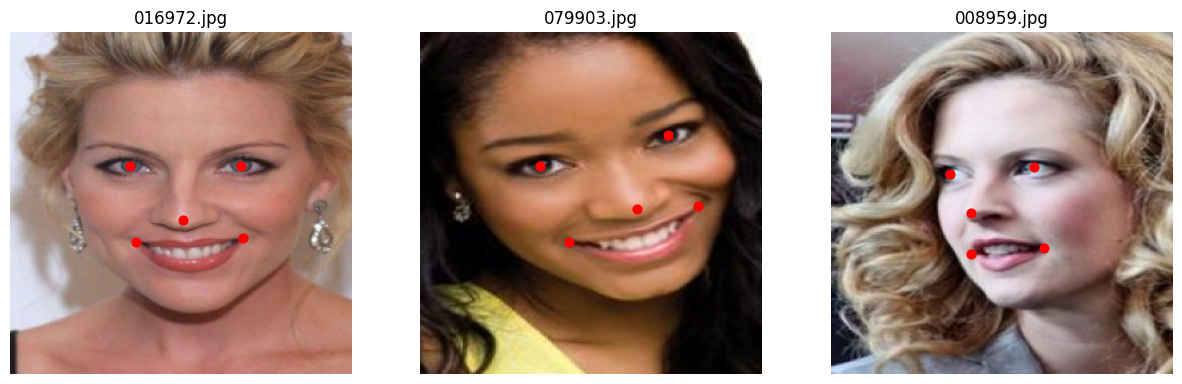

In [ ]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# ПУТИ К ФАЙЛАМ
PROJECT_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'
BBOX_FILE = os.path.join(PROJECT_DIR, 'CelebA/Anno/list_bbox_celeba.txt')
LANDMARKS_FILE = os.path.join(PROJECT_DIR, 'CelebA/Anno/list_landmarks_celeba.txt')

GDRIVE_OUTPUT_DIR = os.path.join(PROJECT_DIR, 'Dataset')

# Локальная папка, где лежат распакованные оригиналы из dataset.zip
IMAGES_SRC_DIR = '/content/dataset'

PADDING_RATIO = 0.13
TARGET_SIZE = 256

# 1. Загружаем данные
df_bbox = pd.read_csv(BBOX_FILE, skiprows=2, header=None, sep=r'\s+',
                      names=['image_id', 'x_1', 'y_1', 'width', 'height']).set_index('image_id')

with open(LANDMARKS_FILE, 'r') as f:
    f.readline()
    landmark_headers = f.readline().split()

df_landmarks = pd.read_csv(LANDMARKS_FILE, skiprows=2, header=None, sep=r'\s+',
                           names=['image_id'] + landmark_headers).set_index('image_id')

selected_images = os.listdir(IMAGES_SRC_DIR)
new_landmarks_list = []

# Пересчитываем всё заново с точной проверкой границ
for img_name in selected_images:
    if img_name not in df_bbox.index or img_name not in df_landmarks.index:
        continue

    img_path = os.path.join(IMAGES_SRC_DIR, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue
    h_img, w_img, _ = img.shape

    x = df_bbox.loc[img_name, 'x_1']
    y = df_bbox.loc[img_name, 'y_1']
    w = df_bbox.loc[img_name, 'width']
    h = df_bbox.loc[img_name, 'height']

    # Считаем паддинг
    pad_w = int(w * PADDING_RATIO)
    pad_h = int(h * PADDING_RATIO)

    # Строгие координаты кропа
    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(w_img, x + w + pad_w)
    y2 = min(h_img, y + h + pad_h)

    crop_w = x2 - x1
    crop_h = y2 - y1

    img_record = {'image_id': img_name}

    for i in range(0, len(landmark_headers), 2):
        col_x = landmark_headers[i]
        col_y = landmark_headers[i+1]

        orig_x = df_landmarks.loc[img_name, col_x]
        orig_y = df_landmarks.loc[img_name, col_y]

        # Пересчет: вычитаем координату старта кропа и умножаем на коэф пропорции
        new_x = (orig_x - x1) * (TARGET_SIZE / crop_w)
        new_y = (orig_y - y1) * (TARGET_SIZE / crop_h)

        img_record[col_x] = round(new_x, 2)
        img_record[col_y] = round(new_y, 2)

    new_landmarks_list.append(img_record)

# Перезаписываем наш итоговый CSV на Диск в папку Dataset
df_new_landmarks = pd.DataFrame(new_landmarks_list)
output_csv_path = os.path.join(GDRIVE_OUTPUT_DIR, 'selected_landmarks_256.csv')
df_new_landmarks.to_csv(output_csv_path, index=False)
print(f"Обновленный CSV сохранен по пути: {output_csv_path}")

# ==========================================
# ВИЗУАЛИЗАЦИЯ ДЛЯ ПРОВЕРКИ СЕБЯ
# ==========================================
# Возьмем первые 3 фотки из сгенерированного датафрейма
test_df = df_new_landmarks.head(3)
CROPPED_DIR = '/content/cropped_faces' # Твоя папка с кропами в Колабе

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (index, row) in enumerate(test_df.iterrows()):
    name = row['image_id']
    crop_path = os.path.join(CROPPED_DIR, name)

    if os.path.exists(crop_path):
        crop_img = cv2.imread(crop_path)
        crop_img = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)

        axes[idx].imshow(crop_img)

        # Рисуем 5 точек красными кружками
        axes[idx].scatter([row['lefteye_x'], row['righteye_x'], row['nose_x'], row['leftmouth_x'], row['rightmouth_x']],
                          [row['lefteye_y'], row['righteye_y'], row['nose_y'], row['leftmouth_y'], row['rightmouth_y']],
                          color='red', s=40)
        axes[idx].set_title(name)
        axes[idx].axis('off')

plt.show()

СО второй попытки точки встали сетко куда надо. На сегодня с меня все.

А еще я сейчас заметил что почему то фоток 10195 а не 10005. Так то это не сильно влияет, просто означает что я немного недоглядел))) А в итоге их вообще 13К полуится...

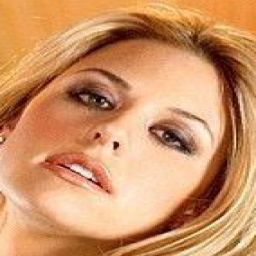

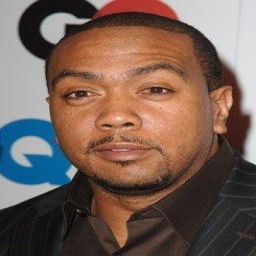

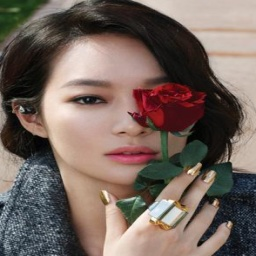

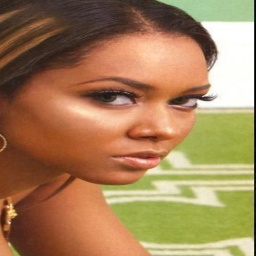

Предпоследняя кстати нам будет мешать при обучении, видимо при разметке celeba она как то ускользнула от них, а я случайно увидел. Не страшно, т.к. я просмотрел много картинок и такая одна. А может ее уже и нет, я же переделываю датасет А-ха-ха-ха-ха

## Обучение нейронки(в широком понимании)

### Данные такие данные

P.S. я принял решение не переобучать нейронку на новом датасете, так как первоисточник тот же, задача та же, обрезка и паддинг не менялся.

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

Переписал функции еще раз

In [ ]:
def create_heatmap(size, landmark, sigma=1.5):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.
    size: (height, width) — обычно (64, 64)
    landmark: (x, y) — координаты точки, уже отмасштабированные под этот размер
    """
    x, y = landmark
    h, w = size

    # Защита от выхода за границы хитмапа
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    # Формула Гауссианы
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap

def landmarks_to_heatmaps(image_shape, landmarks, sigma=1.5):
    """ Преобразует 5 точек лица в 5 хитмапов """
    heatmaps = []
    for (x, y) in landmarks:
        hm = create_heatmap(image_shape, (x, y), sigma=sigma)
        heatmaps.append(hm)
    return np.array(heatmaps, dtype=np.float32)

Просто удобный класс с датасетом для торча. Так же во имя ограничения по памяти heatmap'ы будут 64*64 а не 256*256. Вроде как так было и в статье, но не берусь утверждать.

In [ ]:
class FaceLandmarksDataset(Dataset):
    def __init__(self, csv_file, img_dir, img_size=256, heatmap_size=64):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.img_size = img_size
        self.heatmap_size = heatmap_size

        # Стандартные трансформации: переводим картинку в тензор и нормализуем [0, 1]
        self.transform = transforms.Compose([
            transforms.ToTensor(),
        ])

        # Список названий колонок с координатами в нашем CSV
        self.landmark_cols = [
            'lefteye_x', 'lefteye_y',
            'righteye_x', 'righteye_y',
            'nose_x', 'nose_y',
            'leftmouth_x', 'leftmouth_y',
            'rightmouth_x', 'rightmouth_y'
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_id']
        img_path = os.path.join(self.img_dir, img_name)

        # Читаем картинку
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Применяем трансформации PyTorch (размер уже 256x256 из прошлого шага)
        img_tensor = self.transform(img)

        # Достаем голые координаты точек
        coords = row[self.landmark_cols].values.astype(np.float32) # Массив из 10 чисел
        coords = coords.reshape(-1, 2) # Превращаем в список из 5 пар [(x, y), ...]

        # Магия: так как картинка 256x256, а хитмап нам нужен 64x64,
        # уменьшаем координаты ровно в 4 раза (256 / 64 = 4)
        scale_factor = self.heatmap_size / self.img_size
        scaled_coords = coords * scale_factor

        # Генерируем хитмапы размером (64, 64)
        heatmaps = landmarks_to_heatmaps((self.heatmap_size, self.heatmap_size), scaled_coords, sigma=1.5)
        heatmaps_tensor = torch.from_numpy(heatmaps)

        return img_tensor, heatmaps_tensor

Инициализация датасетов

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'
CSV_FILE = os.path.join(PROJECT_DIR, 'selected_landmarks_256.csv')
LOCAL_IMG_DIR = '/content/cropped_images'

# Создаем полный датасет
full_dataset = FaceLandmarksDataset(csv_file=CSV_FILE, img_dir=LOCAL_IMG_DIR)

# Делим в пропорции 90% на обучение, 10% на валидацию
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Фиксируем генератор случайных чисел для воспроизводимости
torch.manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Настраиваем DataLoader'ы. Батч берем 32 (оптимально для VRAM)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=False)

print(f"Пайплайн данных готов!")
print(f"Размер обучающей выборки: {len(train_dataset)} картинок")
print(f"Размер валидационной выборки: {len(val_dataset)} картинок")

Пайплайн данных готов!
Размер обучающей выборки: 9175 картинок
Размер валидационной выборки: 1020 картинок


### Архитектура нейронки

In [ ]:
import torch
import torch.nn as nn

Этот класс уже был дан в задании

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

Один HOURGLASS блок

In [ ]:
class Hourglass(nn.Module):
    def __init__(self, depth, num_channels):
        """
        depth: сколько раз мы сжимаем изображение (глубина рекурсии)
        num_channels: количество каналов, проходящих через блоки
        """
        super().__init__()
        self.depth = depth

        # Верхняя ветка (Skip connection на текущем разрешении)
        self.up_residual = ResidualBlock(num_channels, num_channels)

        # Нижняя ветка (Сжатие разрешения)
        self.downsample = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down_residual = ResidualBlock(num_channels, num_channels)

        # Рекурсивный шаг: если глубина больше 1, внутри сидит еще один Hourglass
        if self.depth > 1:
            self.inner_hg = Hourglass(depth - 1, num_channels)
        else:
            # Самое «узкое» место песочных часов (BottleNeck)
            self.inner_hg = ResidualBlock(num_channels, num_channels)

        # Восстановление разрешения (Нижняя ветка после сужения)
        self.post_inner_residual = ResidualBlock(num_channels, num_channels)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # Верхний путь (копируем признаки текущего уровня разрешения)
        up_features = self.up_residual(x)

        # Нижний путь (сжимаем пространственный размер в 2 раза)
        down = self.downsample(x)
        down = self.down_residual(down)
        inner = self.inner_hg(down)

        # Восстанавливаем размер обратно
        up = self.post_inner_residual(inner)
        up = self.upsample(up)

        # Складываем верхний (Skip) путь и восстановленный нижний (как в U-Net)
        return up_features + up

Сборка всей неронки. Я не знаю что тут еще подробнее прописать. Максимум то что я выбрал количество блоков как 2, в официальной статье 8, но я решил посмотреть, если хорошо обучиться так то пусть так. Ну а если нет то переучу на 4

In [ ]:
class StackedHourglassNet(nn.Module):
    def __init__(self, num_stacks=2, num_channels=128, num_classes=5):
        """
        num_stacks: сколько «песочных часов» ставим друг за другом
        num_channels: внутреннее число фичей в латентном пространстве
        num_classes: 5 хитмапов на выходе (по числу ключевых точек)
        """
        super().__init__()
        self.num_stacks = num_stacks

        # Front-end: Сжимаем входное изображение с 256x256 до латентного 64x64
        self.pre_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3), # 256x256 -> 128x128
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64, 128),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # 128x128 -> 64x64
            ResidualBlock(128, num_channels)
        )

        # Динамически создаем списки слоев для каждого стека
        self.hg_blocks = nn.ModuleList()
        self.res_blocks = nn.ModuleList()
        self.fc_blocks = nn.ModuleList()
        self.score_heads = nn.ModuleList()
        self.merge_preds = nn.ModuleList()
        self.merge_feats = nn.ModuleList()

        for i in range(num_stacks):
            # Блок «песочных часов» с глубиной сжатия 4 (64x64 -> 32x32 -> 16x16 -> 8x8 -> 4x4)
            self.hg_blocks.append(Hourglass(depth=4, num_channels=num_channels))

            # Линейные/сверточные слои после песочных часов для агрегации фичей
            self.res_blocks.append(ResidualBlock(num_channels, num_channels))
            self.fc_blocks.append(nn.Sequential(
                nn.Conv2d(num_channels, num_channels, kernel_size=1),
                nn.BatchNorm2d(num_channels),
                nn.ReLU(inplace=True)
            ))

            # Предсказательная голова (выдает 5 хитмапов)
            self.score_heads.append(nn.Conv2d(num_channels, num_classes, kernel_size=1))

            # Слои для проброса признаков на следующий стек (если это не последние «часы»)
            if i < num_stacks - 1:
                self.merge_preds.append(nn.Conv2d(num_classes, num_channels, kernel_size=1))
                self.merge_feats.append(nn.Conv2d(num_channels, num_channels, kernel_size=1))

    def forward(self, x):
        x = self.pre_conv(x)

        outputs = []
        for i in range(self.num_stacks):
            # Проход через i-й блок песочных часов
            hg = self.hg_blocks[i](x)
            res = self.res_blocks[i](hg)
            fc = self.fc_blocks[i](res)

            # Получаем промежуточную (или финальную) хитмапу
            score = self.score_heads[i](fc)
            outputs.append(score)

            # Если впереди есть еще один стек, подмешиваем текущие предсказания к признакам
            if i < self.num_stacks - 1:
                fc_ = self.merge_feats[i](fc)
                score_ = self.merge_preds[i](score)
                x = x + fc_ + score_

        return outputs # Возвращаем список хитмапов со всех голов для лосса

print("Архитектура Stacked Hourglass Network успешно скомпилирована!")

Архитектура Stacked Hourglass Network успешно скомпилирована!


### Обучение

Помимо простого обучения я сделал на каждой эпохе вывод изображений с heatmap'ами. Для наглядности. Так же юыло приянто решение сохранять веса на каждом шаге, но только если метрика шагнула выше.

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

Настройки

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Обучение будет идти на устройстве: {device}")

# Инициализируем нашу сеть (2 стека, 128 каналов, 5 точек)
model = StackedHourglassNet(num_stacks=2, num_channels=128, num_classes=5).to(device)

# Функция потерь и Оптимизатор (стандарт для Hourglass)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Путь для сохранения лучших весов на Google Диск
WEIGHTS_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/weights'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
best_weights_path = os.path.join(WEIGHTS_DIR, 'hourglass_best.pth')

Обучение будет идти на устройстве: cuda


Через эту функцию я буду каждую эпоху выводить картинки с heatmap'ами

In [ ]:
def visualize_progress(model, dataset, device, epoch):
    """ Берёт 3 фиксированные картинки и показывает прогресс предсказания хитмапов """
    model.eval()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Зафиксируем индексы картинок для отображения, чтобы видеть прогресс на одних и тех же лицах
    indices = [0, 10, 20]

    with torch.no_grad():
        for idx, img_idx in enumerate(indices):
            img_tensor, true_hm = dataset[img_idx]

            # Добавляем фейковый размер батча [1, 3, 256, 256] и кидаем на GPU
            input_tensor = img_tensor.unsqueeze(0).to(device)

            # Прогон через сеть (берем выход последней, 2-й головы)
            outputs = model(input_tensor)
            pred_hm = outputs[-1].squeeze(0).cpu().numpy() # Размер [5, 64, 64]

            # Конвертируем тензор картинки обратно в нормальный вид для отображения [256, 256, 3]
            img_show = img_tensor.permute(1, 2, 0).numpy()

            # Схлопываем 5 каналов хитмапов в один суммарный для наглядности
            pred_hm_sum = pred_hm.sum(axis=0)

            # Шаг ресайза хитмапа обратно до 256x256, чтобы наложить на картинку
            pred_hm_resized = cv2.resize(pred_hm_sum, (256, 256))

            # Рисуем лицо, а поверх накладываем тепловую карту полупрозрачным слоем (jet куб)
            axes[idx].imshow(img_show)
            axes[idx].imshow(pred_hm_resized, cmap='jet', alpha=0.4)
            axes[idx].set_title(f"Эпоха {epoch} | Лицо {img_idx}")
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

Обучение

In [ ]:
NUM_EPOCHS = 10 # Для начала 10 эпох хватит, чтобы увидеть отличный результат
best_val_loss = float('inf')

print("Стартуем обучение...")

for epoch in range(1, NUM_EPOCHS + 1):
    # --- ЭТАП ОБУЧЕНИЯ ---
    model.train()
    train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Эпоха {epoch}/{NUM_EPOCHS} [Train]")
    for images, targets in train_bar:
        images = images.to(device)
        targets = targets.to(device) # Размер [batch, 5, 64, 64]

        optimizer.zero_grad()

        # Forward pass: получаем список выходов со всех голов сети
        outputs = model(images)

        # Intermediate Supervision: считаем лосс для каждой головы и суммируем
        loss_list = [criterion(output, targets) for output in outputs]
        total_loss = sum(loss_list)

        # Backward pass и шаг оптимизатора
        total_loss.backward()
        optimizer.step()

        train_loss += total_loss.item()
        train_bar.set_postfix({'loss': f"{total_loss.item():.5f}"})

    avg_train_loss = train_loss / len(train_loader)

    # --- ЭТАП ВАЛИДАЦИИ ---
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss_list = [criterion(output, targets) for output in outputs]
            total_loss = sum(loss_list)

            val_loss += total_loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Выводим текстовые логи
    print(f"\n=> Эпоха {epoch} завершена | Средний Train Loss: {avg_train_loss:.5f} | Средний Val Loss: {avg_val_loss:.5f}")

    # Визуализируем текущее качество предсказания точек на экране
    visualize_progress(model, val_dataset, device, epoch)

    # Проверяем рекорд по Val Loss и сохраняем лучшие веса на Гугл Диск
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_weights_path)
        print(f"🔥 Новое лучшее качество! Веса сохранены на Гугл Диск: {best_weights_path}\n")
    else:
        print("Качество не улучшилось, пропускаем сохранение.\n")

print("=== ОБУЧЕНИЕ ПОЛНОСТЬЮ ЗАВЕРШЕНО ===")

Output hidden; open in https://colab.research.google.com to view.

## Выравнивание по предсказанным точкам

Существует множество вариантов, как по полученным точкам правильно преобразовать картинку. Главное, что вам нужно понимать - **это задача классического компьютерного зрения** и решается при помощи математики, без нейронок. Вдаваться в подробности конкретных алгоритмов мы не будем.

Можно использовать аффинное преобразование, тогда потребуется только 3 точки, можно, например, искать матрицу гомографии, где может быть использовано больше точек, а может быть, есть еще что-то. Реализовывать эти алгоритмы самим не нужно. Достаточно провести небольшой ресерч и найти готовое решение (но **не готовую нейронку для выравнивания**), лишь бы оно работало. Количество используемых точек тоже выбирайте сами, подойдет любой вариант. Условный ориентир для поиска - библиотека **opencv**. Обязательно приведите примеры того, как работает ваш алгоритм.

Я выбрал Аффинное преобразование, так как о нем писали выше, а автор задания фигни не посоветует.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'
CELEBA_DIR = os.path.join(PROJECT_DIR, 'CelebA')
IDENTITY_FILE = os.path.join(CELEBA_DIR, 'Anno/identity_CelebA.txt')

# Целевая папка для результатов
GDRIVE_OUTPUT_DIR = os.path.join(PROJECT_DIR, 'Dataset')

# Используем локальный ZIP, созданный на прошлом шаге
SRC_ZIP = os.path.join(GDRIVE_OUTPUT_DIR, 'cropped_dataset.zip')
INPUT_CSV = os.path.join(GDRIVE_OUTPUT_DIR, 'selected_landmarks_256.csv')

LOCAL_SRC_DIR = '/content/cropped_images'
LOCAL_DST_TRAIN = '/content/aligned_images/train'
LOCAL_DST_TEST = '/content/aligned_images/test'

os.makedirs(LOCAL_DST_TRAIN, exist_ok=True)
os.makedirs(LOCAL_DST_TEST, exist_ok=True)

DESIRED_LEFT_EYE = (80.0, 96.0)
DESIRED_RIGHT_EYE = (176.0, 96.0)


Если что я прописываю это каждый раз, потому что делаю задание уже как пятый день. Просто не хочу лазить по ноутбуку и выбирать яейки которые должны были быть запущены. Пусть каждая часть работает сама.

In [ ]:
# Распаковываем локальные кропы, если еще не распакованы
if not os.path.exists(LOCAL_SRC_DIR) or len(os.listdir(LOCAL_SRC_DIR)) == 0:
    print("Распаковываем исходные кропы...")
    os.makedirs(LOCAL_SRC_DIR, exist_ok=True)
    !unzip -q "{SRC_ZIP}" -d {LOCAL_SRC_DIR}

df = pd.read_csv(INPUT_CSV)

# Подгружаем identity, чтобы знать ID людей для разбиения
df_ident = pd.read_csv(IDENTITY_FILE, sep=r'\s+', header=None, names=['image_id', 'person_id'])
df = pd.merge(df, df_ident, on='image_id', how='inner')

Распаковываем исходные кропы...


Я решил разбить все на два архива. Трейновый и тестовый. Во второй пойдут 20% фото каждого человека.

In [ ]:
print("Разделяем выборку на Train и Test...")
# Выделяем тестовую часть (по 20% из каждой группы person_id)
df_test = df.groupby('person_id', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))
test_image_ids = set(df_test['image_id'])

# Всё остальное уходит в train
df_train = df[~df['image_id'].isin(test_image_ids)].copy()

print(f"Всего картинок: {len(df)} | В Train: {len(df_train)} | В Test: {len(df_test)}")

Разделяем выборку на Train и Test...
Всего картинок: 13089 | В Train: 10425 | В Test: 2664


/tmp/ipykernel_10921/2113606910.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test = df.groupby('person_id', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))


Это функция выравнивания.

In [ ]:
def align_face_and_points(img, points, desired_l_eye=DESIRED_LEFT_EYE, desired_r_eye=DESIRED_RIGHT_EYE):
    l_eye_curr = points[0]
    r_eye_curr = points[1]

    d_y = r_eye_curr[1] - l_eye_curr[1]
    d_x = r_eye_curr[0] - l_eye_curr[0]
    angle = np.degrees(np.arctan2(d_y, d_x))

    dist_curr = np.sqrt(d_x**2 + d_y**2)
    dist_desired = desired_r_eye[0] - desired_l_eye[0]
    scale = dist_desired / dist_curr

    eye_center = (float((l_eye_curr[0] + r_eye_curr[0]) / 2), float((l_eye_curr[1] + r_eye_curr[1]) / 2))

    M = cv2.getRotationMatrix2D(eye_center, angle, scale)

    desired_eye_center_x = (desired_l_eye[0] + desired_r_eye[0]) / 2
    desired_eye_center_y = (desired_l_eye[1] + desired_r_eye[1]) / 2

    M[0, 2] += desired_eye_center_x - eye_center[0]
    M[1, 2] += desired_eye_center_y - eye_center[1]

    aligned_img = cv2.warpAffine(img, M, (256, 256), flags=cv2.INTER_CUBIC)

    aligned_points = []
    for (x, y) in points:
        new_x = M[0, 0] * x + M[0, 1] * y + M[0, 2]
        new_y = M[1, 0] * x + M[1, 1] * y + M[1, 2]
        aligned_points.append((round(new_x, 2), round(new_y, 2)))

    return aligned_img, aligned_points

Запуск аффинного выравнивания датасета...


100%|██████████| 13089/13089 [01:03<00:00, 204.59it/s]


Файлы разметки сохранены:
1. /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/aligned_landmarks_train.csv
2. /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/aligned_landmarks_test.csv


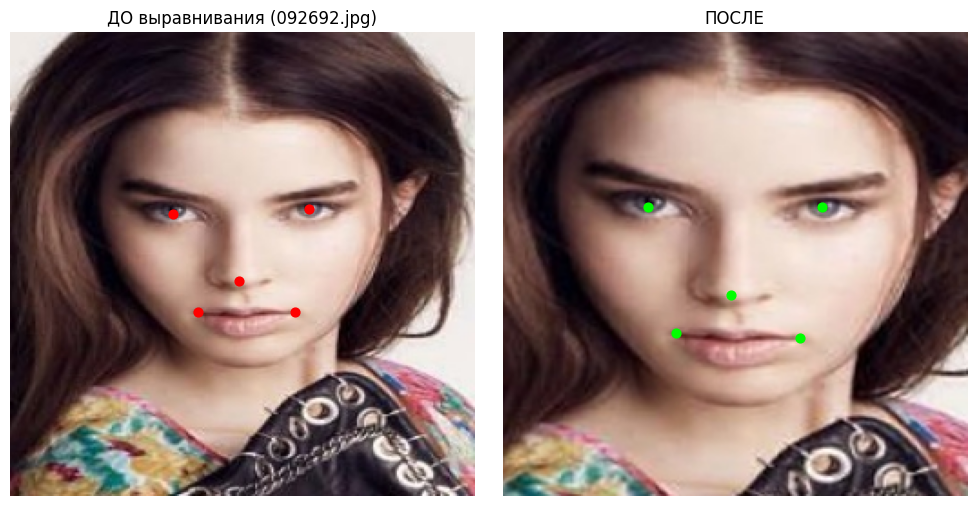

Упаковываем TRAIN датасет в ZIP...
Упаковываем TEST датасет в ZIP...
=== ВСЁ УСПЕШНО РАЗБИТО И СОХРАНЕНО В /Dataset ===


In [ ]:
print("Запуск аффинного выравнивания датасета...")
aligned_train_landmarks = []
aligned_test_landmarks = []
example_data = None

for idx, row in tqdm(df.iterrows(), total=len(df)):
    img_name = row['image_id']
    img_path = os.path.join(LOCAL_SRC_DIR, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    pts = [
        (row['lefteye_x'], row['lefteye_y']),
        (row['righteye_x'], row['righteye_y']),
        (row['nose_x'], row['nose_y']),
        (row['leftmouth_x'], row['leftmouth_y']),
        (row['rightmouth_x'], row['rightmouth_y'])
    ]

    aligned_img, n_pts = align_face_and_points(img, pts)

    # Определяем целевую локальную папку и пишем в нужный список разметки
    record = {
        'image_id': img_name, 'person_id': row['person_id'],
        'lefteye_x': n_pts[0][0], 'lefteye_y': n_pts[0][1],
        'righteye_x': n_pts[1][0], 'righteye_y': n_pts[1][1],
        'nose_x': n_pts[2][0], 'nose_y': n_pts[2][1],
        'leftmouth_x': n_pts[3][0], 'leftmouth_y': n_pts[3][1],
        'rightmouth_x': n_pts[4][0], 'rightmouth_y': n_pts[4][1]
    }

    if img_name in test_image_ids:
        cv2.imwrite(os.path.join(LOCAL_DST_TEST, img_name), aligned_img)
        aligned_test_landmarks.append(record)
    else:
        cv2.imwrite(os.path.join(LOCAL_DST_TRAIN, img_name), aligned_img)
        aligned_train_landmarks.append(record)

    if idx == 5:
        example_data = (img.copy(), pts, aligned_img.copy(), n_pts, img_name)

# Сохраняем новые файлы разметки на Диск в Dataset
df_aligned_train = pd.DataFrame(aligned_train_landmarks)
df_aligned_test = pd.DataFrame(aligned_test_landmarks)

train_csv_path = os.path.join(GDRIVE_OUTPUT_DIR, 'aligned_landmarks_train.csv')
test_csv_path = os.path.join(GDRIVE_OUTPUT_DIR, 'aligned_landmarks_test.csv')

df_aligned_train.to_csv(train_csv_path, index=False)
df_aligned_test.to_csv(test_csv_path, index=False)

print(f"Файлы разметки сохранены:\n1. {train_csv_path}\n2. {test_csv_path}")


if example_data:
    orig_img, o_pts, al_img, a_pts, name = example_data
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    axes[0].imshow(orig_img)
    axes[0].scatter([p[0] for p in o_pts], [p[1] for p in o_pts], color='red', s=40)
    axes[0].set_title(f"ДО выравнивания ({name})")
    axes[0].axis('off')

    al_img = cv2.cvtColor(al_img, cv2.COLOR_BGR2RGB)
    axes[1].imshow(al_img)
    axes[1].scatter([p[0] for p in a_pts], [p[1] for p in a_pts], color='lime', s=40)
    axes[1].set_title("ПОСЛЕ")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


print("Упаковываем TRAIN датасет в ZIP...")
shutil.make_archive('/content/aligned_train', 'zip', LOCAL_DST_TRAIN)
shutil.copy('/content/aligned_train.zip', os.path.join(GDRIVE_OUTPUT_DIR, 'aligned_train.zip'))

print("Упаковываем TEST датасет в ZIP...")
shutil.make_archive('/content/aligned_test', 'zip', LOCAL_DST_TEST)
shutil.copy('/content/aligned_test.zip', os.path.join(GDRIVE_OUTPUT_DIR, 'aligned_test.zip'))

print("=== ВСЁ УСПЕШНО РАЗБИТО И СОХРАНЕНО В /Dataset ===")

Новые файлы сохранены. Заодно я навсякий сохраню новый ключевые точки. Опять же, пусть будут.

То что я делал паддинг 13%, с одной стороны может показаться плохим, так как нейронке лучше бы получать изображения без фона и тд. Но вот после преобразования все точки так и так встанут на свои места, а вот если до этого часть лица была не видна, то простой математикой е ене вернешь.

# Создание валидационного датасета

Это маленькое дополнение понадобилось позже, при тестировании ArcFace. Так как она может обобщать неизвестные лица нужно было проверить это на новых людях(не партия).

Код простой. Я бы сказал что даже и смотреть его не обязательно. Я бы даже сказал нейрокод.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil

# ==========================================
# 1. ПУТИ И НАСТРОЙКИ
# ==========================================
PROJECT_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'
CELEBA_DIR = os.path.join(PROJECT_DIR, 'CelebA')
BBOX_FILE = os.path.join(CELEBA_DIR, 'Anno/list_bbox_celeba.txt')
LANDMARKS_FILE = os.path.join(CELEBA_DIR, 'Anno/list_landmarks_celeba.txt')
ATTR_FILE = os.path.join(CELEBA_DIR, 'Anno/list_attr_celeba.txt')
IDENTITY_FILE = os.path.join(CELEBA_DIR, 'Anno/identity_CelebA.txt')

GDRIVE_OUTPUT_DIR = os.path.join(PROJECT_DIR, 'Dataset')

# Откуда берем распакованное (твои 17k+ картинок)
UNZIPPED_DIR = '/content/temp_faces/img_celeba'

# Временная локальная папка для сохранения результатов выравнивания валидации
LOCAL_VAL_DIR = '/content/aligned_images/val'
if os.path.exists(LOCAL_VAL_DIR):
    shutil.rmtree(LOCAL_VAL_DIR)
os.makedirs(LOCAL_VAL_DIR, exist_ok=True)

# Геометрические константы из прошлых шагов
PADDING_RATIO = 0.13
TARGET_SIZE = 256
DESIRED_LEFT_EYE = (80.0, 96.0)
DESIRED_RIGHT_EYE = (176.0, 96.0)

# ==========================================
# 2. ЗАГРУЗКА ДАННЫХ И ИСКЛЮЧЕНИЕ СТАРОГО ДАТАСЕТА
# ==========================================
print("Загружаем таблицы разметки...")
df_bbox = pd.read_csv(BBOX_FILE, skiprows=2, header=None, sep=r'\s+',
                      names=['image_id', 'x_1', 'y_1', 'width', 'height']).set_index('image_id')

with open(LANDMARKS_FILE, 'r') as f:
    f.readline()
    landmark_headers = f.readline().split()
df_landmarks = pd.read_csv(LANDMARKS_FILE, skiprows=2, header=None, sep=r'\s+',
                           names=['image_id'] + landmark_headers).set_index('image_id')

df_attr = pd.read_csv(ATTR_FILE, skiprows=2, header=None, sep=r'\s+',
                      names=['image_id'] + open(ATTR_FILE).readlines()[1].split())
df_ident = pd.read_csv(IDENTITY_FILE, sep=r'\s+', header=None, names=['image_id', 'person_id'])

# Объединяем разметку для поиска кандидатов
df_total = pd.merge(df_attr, df_ident, on='image_id')

# Узнаем, какие люди уже были использованы в основном датасете, чтобы не взять их повторно
existing_train_path = os.path.join(GDRIVE_OUTPUT_DIR, 'aligned_landmarks_train.csv')
used_persons = set()
if os.path.exists(existing_train_path):
    df_used = pd.read_csv(existing_train_path)
    used_persons = set(df_used['person_id'].unique())
    print(f"Найдено {len(used_persons)} людей, которых нужно исключить из валидации.")

# Фильтр по качеству + проверяем, что картинка РЕАЛЬНО распакована в temp_faces
available_images = set(os.listdir(UNZIPPED_DIR))
filtered_df = df_total[
    (df_total['Blurry'] == -1) &
    (df_total['Eyeglasses'] == -1) &
    (df_total['Wearing_Hat'] == -1) &
    (df_total['Bangs'] == -1) &
    (df_total['Narrow_Eyes'] == -1) &
    (df_total['image_id'].isin(available_images)) &
    (~df_total['person_id'].isin(used_persons)) # Исключаем "знакомых" людей
]

# ==========================================
# 3. ОТБОР ВАЛИДАЦИОННЫХ КАНДИДАТОВ (50 человек по 4-6 фото)
# ==========================================
person_counts = filtered_df['person_id'].value_counts()
valid_persons = person_counts[person_counts >= 4].index

if len(valid_persons) < 50:
    print(f"⚠️ Нашлось только {len(valid_persons)} подходящих новых людей. Берем всех.")
    selected_val_persons = valid_persons
else:
    selected_val_persons = valid_persons[:50]

df_val_final = filtered_df[filtered_df['person_id'].isin(selected_val_persons)]
df_val_final = df_val_final.groupby('person_id').head(6)

print(f"Итого отобрано для валидации: {df_val_final['person_id'].nunique()} людей, {len(df_val_final)} изображений.")

# ==========================================
# 4. ФУНКЦИЯ АФФИННОГО ВЫРАВНИВАНИЯ (Принимает уже 256x256)
# ==========================================
def align_face_and_points(img, points, desired_l_eye=DESIRED_LEFT_EYE, desired_r_eye=DESIRED_RIGHT_EYE):
    l_eye_curr = points[0]
    r_eye_curr = points[1]

    d_y = r_eye_curr[1] - l_eye_curr[1]
    d_x = r_eye_curr[0] - l_eye_curr[0]
    angle = np.degrees(np.arctan2(d_y, d_x))

    dist_curr = np.sqrt(d_x**2 + d_y**2)
    dist_desired = desired_r_eye[0] - desired_l_eye[0]
    scale = dist_desired / dist_curr

    eye_center = (float((l_eye_curr[0] + r_eye_curr[0]) / 2), float((l_eye_curr[1] + r_eye_curr[1]) / 2))
    M = cv2.getRotationMatrix2D(eye_center, angle, scale)

    desired_eye_center_x = (desired_l_eye[0] + desired_r_eye[0]) / 2
    desired_eye_center_y = (desired_l_eye[1] + desired_r_eye[1]) / 2
    M[0, 2] += desired_eye_center_x - eye_center[0]
    M[1, 2] += desired_eye_center_y - eye_center[1]

    # img здесь уже гарантированно 256x256
    aligned_img = cv2.warpAffine(img, M, (TARGET_SIZE, TARGET_SIZE), flags=cv2.INTER_CUBIC)

    aligned_points = []
    for (x, y) in points:
        new_x = M[0, 0] * x + M[0, 1] * y + M[0, 2]
        new_y = M[1, 0] * x + M[1, 1] * y + M[1, 2]
        aligned_points.append((round(new_x, 2), round(new_y, 2)))

    return aligned_img, aligned_points

# ==========================================
# 5. ИСПРАВЛЕННЫЙ ЦИКЛ ОБРАБОТКИ
# ==========================================
print("Запуск корректной обработки: Кроп -> Ресайз -> Аффинное выравнивание...")
val_landmarks_records = []

for _, row in tqdm(df_val_final.iterrows(), total=len(df_val_final)):
    img_name = row['image_id']
    if img_name not in df_bbox.index or img_name not in df_landmarks.index:
        continue

    img_path = os.path.join(UNZIPPED_DIR, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    h_img, w_img, _ = img.shape

    # 1. Считаем координаты кропа с паддингом
    x, y = df_bbox.loc[img_name, 'x_1'], df_bbox.loc[img_name, 'y_1']
    w, h = df_bbox.loc[img_name, 'width'], df_bbox.loc[img_name, 'height']

    pad_w, pad_h = int(w * PADDING_RATIO), int(h * PADDING_RATIO)
    x1, y1 = max(0, x - pad_w), max(0, y - pad_h)
    x2, y2 = min(w_img, x + w + pad_w), min(h_img, y + h + pad_h)
    crop_w, crop_h = x2 - x1, y2 - y1

    # 2. Вырезаем лицо
    cropped_face = img[y1:y2, x1:x2]

    # [FIX]: СРАЗУ делаем ресайз кропнутого лица до 256x256 перед выравниванием!
    resized_face = cv2.resize(cropped_face, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)

    # 3. Пересчитываем исходные landmarks под масштаб resized_face (256x256)
    pts = []
    for i in range(0, len(landmark_headers), 2):
        col_x, col_y = landmark_headers[i], landmark_headers[i+1]
        orig_x = df_landmarks.loc[img_name, col_x]
        orig_y = df_landmarks.loc[img_name, col_y]

        # Точки проецируются на плоскость 256x256
        new_x = (orig_x - x1) * (TARGET_SIZE / crop_w)
        new_y = (orig_y - y1) * (TARGET_SIZE / crop_h)
        pts.append((new_x, new_y))

    # 4. Передаем в аффинное выравнивание УЖЕ стандартизированную по размеру картинку
    aligned_img, n_pts = align_face_and_points(resized_face, pts)

    # Сохраняем результат
    cv2.imwrite(os.path.join(LOCAL_VAL_DIR, img_name), aligned_img)

    val_landmarks_records.append({
        'image_id': img_name, 'person_id': row['person_id'],
        'lefteye_x': n_pts[0][0], 'lefteye_y': n_pts[0][1],
        'righteye_x': n_pts[1][0], 'righteye_y': n_pts[1][1],
        'nose_x': n_pts[2][0], 'nose_y': n_pts[2][1],
        'leftmouth_x': n_pts[3][0], 'leftmouth_y': n_pts[3][1],
        'rightmouth_x': n_pts[4][0], 'rightmouth_y': n_pts[4][1]
    })

# ==========================================
# 6. СОХРАНЕНИЕ CSV И ZIP НА GOOGLE ДИСК
# ==========================================
df_val_csv = pd.DataFrame(val_landmarks_records)
val_csv_path = os.path.join(GDRIVE_OUTPUT_DIR, 'aligned_landmarks_val.csv')
df_val_csv.to_csv(val_csv_path, index=False)
print(f"Валидационный CSV сохранен по пути: {val_csv_path}")

print("Упаковываем VALIDATION датасет в ZIP...")
shutil.make_archive('/content/aligned_val', 'zip', LOCAL_VAL_DIR)
shutil.copy('/content/aligned_val.zip', os.path.join(GDRIVE_OUTPUT_DIR, 'aligned_val.zip'))

print("=== ВСЁ ИСПРАВЛЕНО И ГОТОВО ===")

Загружаем таблицы разметки...
Найдено 700 людей, которых нужно исключить из валидации.
Итого отобрано для валидации: 50 людей, 300 изображений.
Запуск корректной обработки: Кроп -> Ресайз -> Аффинное выравнивание...


100%|██████████| 300/300 [00:02<00:00, 106.07it/s]


Валидационный CSV сохранен по пути: /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/aligned_landmarks_val.csv
Упаковываем VALIDATION датасет в ZIP...
=== ВСЁ ИСПРАВЛЕНО И ГОТОВО ===
